In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load data
df = pd.read_csv("/content/smart_meter_data[1].csv") # Assuming the file is uploaded to the Colab session or in the current working directory

explore data

In [ ]:
df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [ ]:
df.shape

(5000, 7)

In [ ]:
df.columns

Index(['Timestamp', 'Electricity_Consumed', 'Temperature', 'Humidity',
       'Wind_Speed', 'Avg_Past_Consumption', 'Anomaly_Label'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB


In [ ]:
df.describe()

,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.376677,0.525069,0.497632,0.464628,0.458738
std,0.164117,0.135603,0.146781,0.120370,0.146749
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.265349,0.434253,0.398956,0.382906,0.358857
50%,0.377244,0.524052,0.497539,0.464958,0.457814
75%,0.486002,0.617281,0.595359,0.547419,0.555607
max,1.000000,1.000000,1.000000,1.000000,1.000000


Data quality check

In [ ]:
df.isnull().sum()

,0
Timestamp,0
Electricity_Consumed,0
Temperature,0
Humidity,0
Wind_Speed,0
Avg_Past_Consumption,0
Anomaly_Label,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#no missing value & duplicated

analysis

In [ ]:
df.mean(numeric_only=True)

,0
Electricity_Consumed,0.376677
Temperature,0.525069
Humidity,0.497632
Wind_Speed,0.464628
Avg_Past_Consumption,0.458738


In [ ]:
print("Max:", df['Electricity_Consumed'].max())
print("Min:", df['Electricity_Consumed'].min())
print("Mean:", df['Electricity_Consumed'].mean())

Max: 1.0
Min: 0.0
Mean: 0.37667745005931613


In [ ]:
df['Anomaly_Label'].value_counts()

,count
Anomaly_Label,
Normal,4750
Abnormal,250


In [ ]:
#الداتا مش متوازنة الموديل هيبصمج

In [ ]:
df.groupby('Anomaly_Label')['Electricity_Consumed'].mean()

,Electricity_Consumed
Anomaly_Label,
Abnormal,0.379039
Normal,0.376553


Data Visualization

Countplot

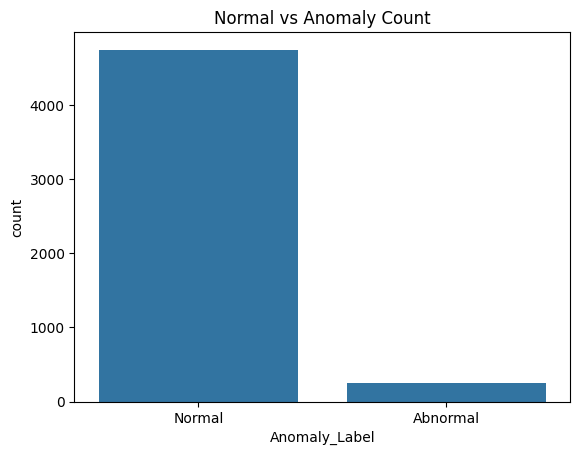

In [ ]:
sns.countplot(x=df['Anomaly_Label'])
plt.title("Normal vs Anomaly Count")
plt.show()

In [ ]:
#dataset is imbalanced (Normal >> Abnormal)

In [ ]:
#هيبصمج بصمجة قوية خلوا بالكم

Histogram

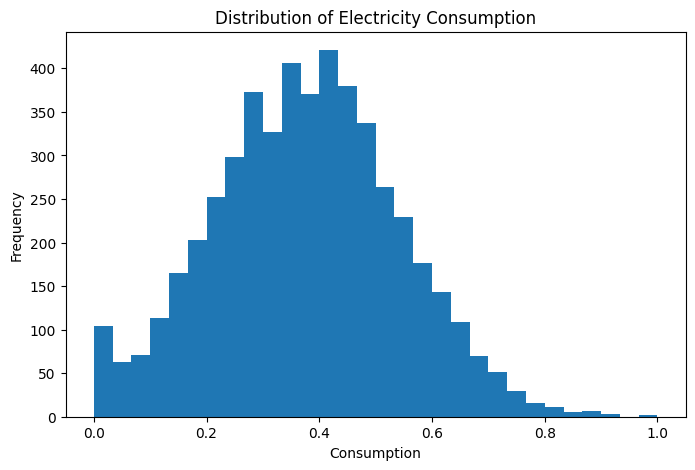

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Electricity_Consumed'], bins=30)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("Consumption")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# اغلب الناس ف الداتا استهلاكها متوسط بس عندنا شوية حرامية ف الاطراف

Boxplot to find outlier

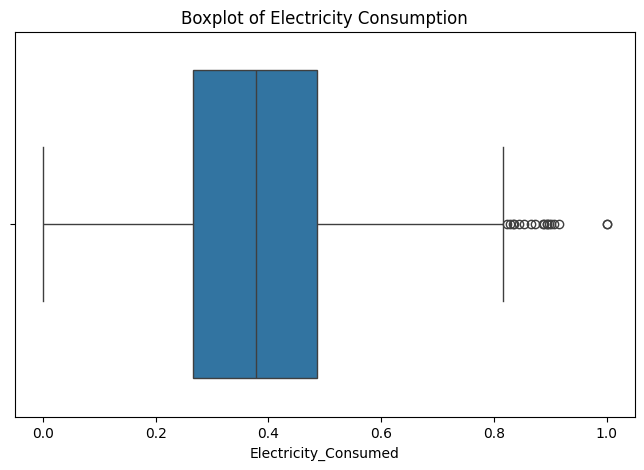

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Electricity_Consumed'])
plt.title("Boxplot of Electricity Consumption")
plt.show()

In [ ]:
#There are outliers in electricity consumption indicating abnormal behavior

In [ ]:
#عندنا شوية نقط بعيد عن الاستهلاك الطبيعي يعني شوية سرقة عايزين الموديل يكتشفها

Heatmap

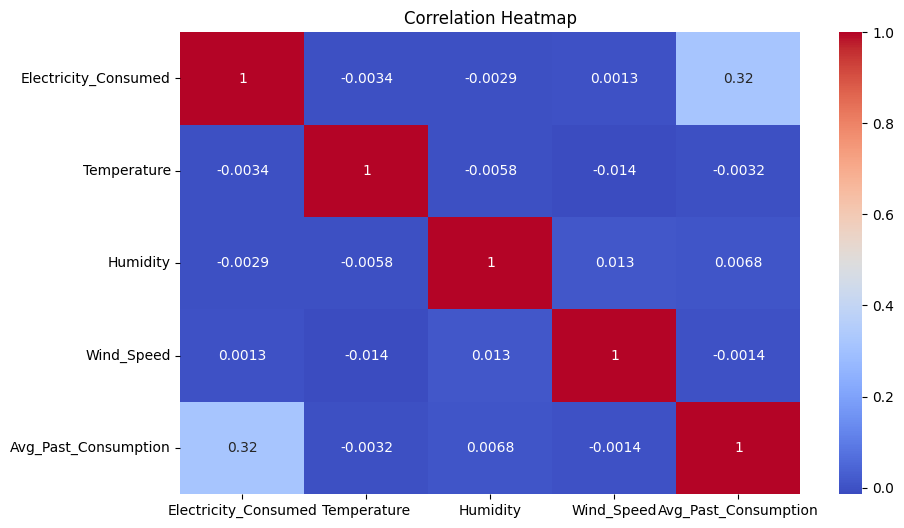

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Scatter

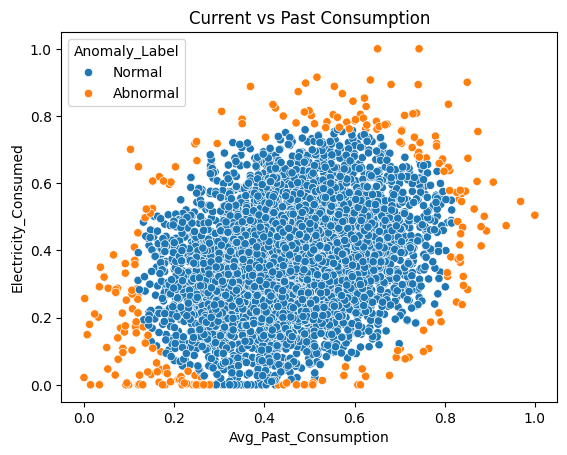

In [ ]:
sns.scatterplot(x=df['Avg_Past_Consumption'], y=df['Electricity_Consumed'], hue=df['Anomaly_Label'])
plt.title("Current vs Past Consumption")
plt.show()

In [ ]:
#Some records don't follow the expected relationship between past and current consumption

In [ ]:
#في استهلاك اتغير بجنون

Time plot

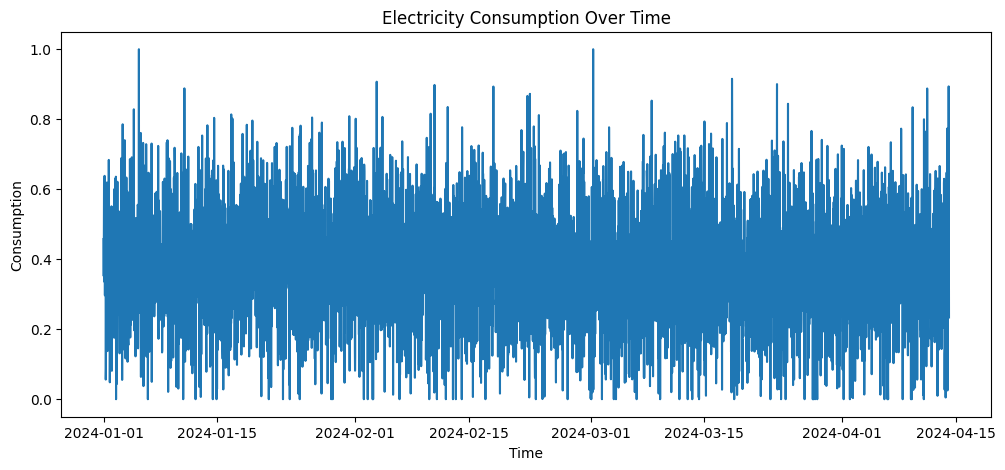

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

plt.figure(figsize=(12,5))
plt.plot(df['Timestamp'], df['Electricity_Consumed'])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.show()

In [ ]:
#هنا بنشوف الاستهلاك بيتغير ازاي بمرور الوقت

In [ ]:
#drop & spike غالبا سرقة

 Prepare feature matrix and target column for the next stage

In [ ]:
X = df[['Electricity_Consumed', 'Temperature', 'Humidity', 'Wind_Speed', 'Avg_Past_Consumption']]
y = df['Anomaly_Label']

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())
print(y.head())

X shape: (5000, 5)
y shape: (5000,)
   Electricity_Consumed  Temperature  Humidity  Wind_Speed  \
0              0.457786     0.469524  0.396368    0.445441   
1              0.351956     0.465545  0.451184    0.458729   
2              0.482948     0.285415  0.408289    0.470360   
3              0.628838     0.482095  0.512308    0.576241   
4              0.335974     0.624741  0.672021    0.373004   

   Avg_Past_Consumption  
0              0.692057  
1              0.539874  
2              0.614724  
3              0.757044  
4              0.673981  
0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
Name: Anomaly_Label, dtype: object


**Note:**

The dataset is imbalanced (Normal > Abnormal)  ▶  (للتأكيد )




**Data preparation**


In [ ]:
# Convert from string to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort data by time for LSTM to ensure correct sequence learning
df = df.sort_values('Timestamp')

df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


**Label Encoding**

In [ ]:
# Convert labels to numeric
df['Anomaly_Label'] = df['Anomaly_Label'].map({
    'Normal': 0,
    'Abnormal': 1
})

df['Anomaly_Label'].value_counts()
#  Normal = 0 , Theft = 1

,count
Anomaly_Label,
0,4750
1,250


**Feature Engineering**

In [ ]:
# Create new feature: difference between current and past consumption that will directly capture abnormal behavior
df['Consumption_Diff'] = (
    df['Electricity_Consumed'] - df['Avg_Past_Consumption']
)

df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Consumption_Diff
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,-0.234272
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,-0.187918
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,-0.131776
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,-0.128206
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,-0.338007


In [ ]:
# Positive values -- ((theft) spike)
# Negative values -- (potential drop)

**Feature Scaling**
(normalizing using MinMaxScaler)

In [ ]:
# Used MinMaxScaler because input should be in a small bounded range because LSTM uses: Sigmoid activation -- outputs between (0,1) ,Tanh activation -- outputs between (-1,1)
# any other scaler will lead to unstable results

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = [
    'Electricity_Consumed',
    'Temperature',
    'Humidity',
    'Wind_Speed',
    'Avg_Past_Consumption',
    'Consumption_Diff'
]

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Consumption_Diff
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,0.336864
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,0.373827
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,0.418596
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,0.421443
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,0.254144



**Train/Test Split**


In [ ]:
# Split based on time
split = int(0.8 * len(df))

train_df = df.iloc[:split]
test_df = df.iloc[split:]

print("Train size:", len(train_df))
print("Test size:", len(test_df))
# To Prevents data leakage

Train size: 4000
Test size: 1000



**Applying SMOTE on training data only**


In [ ]:
from imblearn.over_sampling import SMOTE

X_train = train_df[features]
y_train = train_df['Anomaly_Label']

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE:
 Anomaly_Label
0    3805
1     195
Name: count, dtype: int64

After SMOTE:
 Anomaly_Label
0    3805
1    3805
Name: count, dtype: int64


In [ ]:

# Model learns:Patterns from balanced training data
#Then tested on: Real world data (test set Represents real world data, Still imbalanced (like reality))
# So the accuracy is honest


**Prepare Test Data**
 (nothing changed)


In [ ]:
# Test data must remain realistic
X_test = test_df[features]
y_test = test_df['Anomaly_Label']


**Converts data → sequences**



In [ ]:
# LSTM learns patterns over time from sequences
def create_sequences(X, y, time_steps=10):
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])

    return np.array(X_seq), np.array(y_seq)


**Apply Sequence Creation**



In [ ]:
time_steps = 10

# Training sequences
X_train_seq, y_train_seq = create_sequences(
    X_train_resampled.values,
    y_train_resampled.values,
    time_steps
)

# Testing sequences
X_test_seq, y_test_seq = create_sequences(
    X_test.values,
    y_test.values,
    time_steps
)

print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)

Train shape: (7600, 10, 6)
Test shape: (990, 10, 6)


In [ ]:
df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Consumption_Diff
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,0.336864
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,0.373827
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,0.418596
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,0.421443
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,0.254144


In [ ]:
#  Save TRAIN data (after SMOTE + sequences)


# Flatten sequences to 2D for saving
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)

train_df_final = pd.DataFrame(X_train_flat)
train_df_final['Target'] = y_train_seq

train_df_final.to_csv("train_data_lstm.csv", index=False)


# Save TEST data (original sequences)


X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

test_df_final = pd.DataFrame(X_test_flat)
test_df_final['Target'] = y_test_seq

test_df_final.to_csv("test_data_lstm.csv", index=False)


#  Save MERGED data (train + test)


merged_df = pd.concat([train_df_final, test_df_final], axis=0)

merged_df.to_csv("merged_data_lstm.csv", index=False)


print("Files saved successfully:")
print("- train_data_lstm.csv")
print("- test_data_lstm.csv")
print("- merged_data_lstm.csv")

Files saved successfully:
- train_data_lstm.csv
- test_data_lstm.csv
- merged_data_lstm.csv


# **Model Training**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight


In [ ]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

lstm_model.add(LSTM(256, return_sequences=True))
lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(64, return_sequences=True))
lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
y_prob = lstm_model.predict(X_test_seq)

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step


In [ ]:
y_prob = y_prob.reshape(-1)
print(y_prob[:20])

[0.4970816  0.4974258  0.49752033 0.49781543 0.49751028 0.49831468
 0.49804533 0.49827707 0.4984222  0.49863634 0.49911848 0.49912536
 0.499649   0.49935284 0.49922132 0.4991205  0.4992924  0.49932277
 0.49899077 0.4989523 ]


In [ ]:
# Callbacks

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [ ]:
# Train model
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=24,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.5141 - loss: 0.6921 - val_accuracy: 0.6020 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 2/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.6382 - loss: 0.6106 - val_accuracy: 0.8818 - val_loss: 0.4324 - learning_rate: 0.0010
Epoch 3/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9486 - loss: 0.1669 - val_accuracy: 0.9444 - val_loss: 0.2129 - learning_rate: 0.0010
Epoch 4/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9692 - loss: 0.1176 - val_accuracy: 0.9394 - val_loss: 0.2220 - learning_rate: 0.0010
Epoch 5/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9680 - loss: 0.1198 - val_accuracy: 0.9444 - val_loss: 0.2042 - learning_rate: 0.0010
Epoch 6/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9722 - loss: 0.1045 - val_accuracy: 0.9384 - val_loss: 0.2062 - learning_rate: 0.0010
Epoch 7/24
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9724 - l

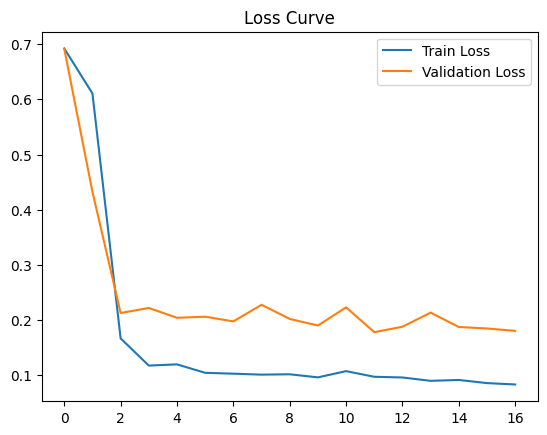

In [ ]:
#  Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

y_prob = lstm_model.predict(X_test_seq)

precision, recall, pr_thresholds = precision_recall_curve(y_test_seq, y_prob)

f1_scores = []

for t in pr_thresholds:
    y_pred = (y_prob > t).astype(int)
    f1_scores.append(f1_score(y_test_seq, y_pred))

best_idx = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx]

print("Best Threshold (PR):", best_threshold_pr)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Best Threshold (PR): 0.13520546


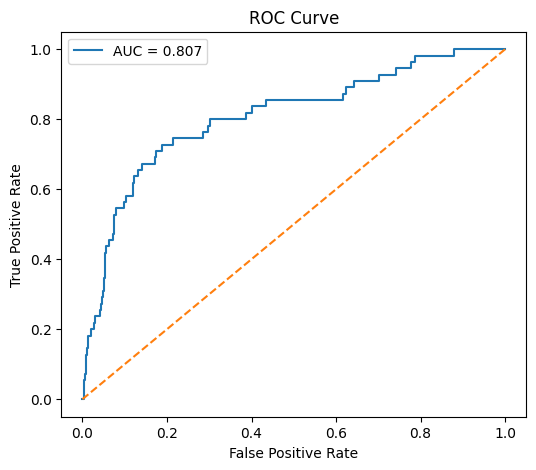

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_test_seq, y_prob)

optimal_idx = np.argmax(tpr - fpr)
best_threshold_roc = roc_thresholds[optimal_idx]

roc_auc = roc_auc_score(y_test_seq, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#  Combine ALL thresholds

thresholds_to_test = [
    0.5, 0.4, 0.3, 0.2, 0.1, 0.08, 0.075, 0.05,
    best_threshold_pr,
    best_threshold_roc
]

# إزالة التكرار
#thresholds_to_test = list(set(thresholds_to_test))

# ترتيبهم
#thresholds_to_test.sort(reverse=True)

# Evaluation Loop

for t in thresholds_to_test:
    y_pred = (y_prob > t).astype(int)

    print(f"\n🔹 Threshold = {t}")
    print(classification_report(y_test_seq, y_pred))


🔹 Threshold = 0.5
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       935
           1       0.42      0.15      0.22        55

    accuracy                           0.94       990
   macro avg       0.69      0.57      0.59       990
weighted avg       0.92      0.94      0.93       990


🔹 Threshold = 0.4
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       935
           1       0.34      0.20      0.25        55

    accuracy                           0.93       990
   macro avg       0.65      0.59      0.61       990
weighted avg       0.92      0.93      0.93       990


🔹 Threshold = 0.3
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       935
           1       0.29      0.24      0.26        55

    accuracy                           0.93       990
   macro avg       0.62      0.60      0.61       990
weighted avg     

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.88      0.92       935
           1       0.23      0.62      0.33        55

    accuracy                           0.86       990
   macro avg       0.60      0.75      0.63       990
weighted avg       0.93      0.86      0.89       990

Confusion Matrix:

[[821 114]
 [ 21  34]]


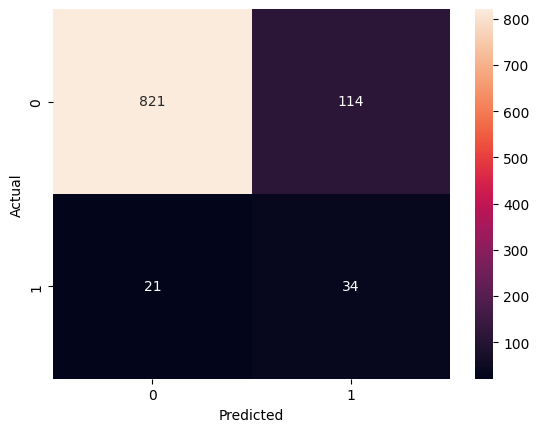

ROC AUC: 0.807175498298493


In [ ]:
# تثبيت threshold لانه افضل واحد عمل توازن ما بين التصنيفين
threshold = 0.075

# تحويل probabilities إلى predictions
y_pred = (y_prob > threshold).astype(int)

#  Evaluation

print("Classification Report:\n")
print(classification_report(y_test_seq, y_pred))

print("Confusion Matrix:\n")
cm = confusion_matrix(y_test_seq, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC
roc = roc_auc_score(y_test_seq, y_prob)
print("ROC AUC:", roc)

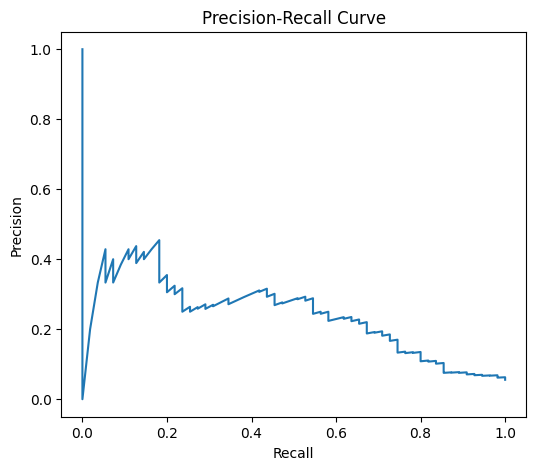

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_seq, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

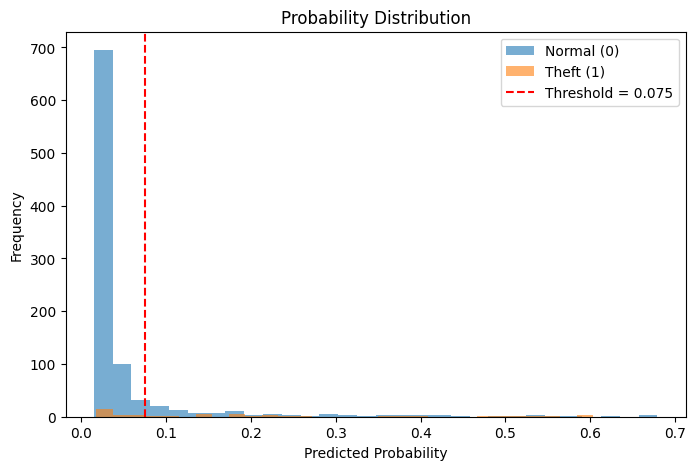

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(y_prob[y_test_seq == 0], bins=30, alpha=0.6, label="Normal (0)")
plt.hist(y_prob[y_test_seq == 1], bins=30, alpha=0.6, label="Theft (1)")

plt.axvline(x=0.075, color='red', linestyle='--', label="Threshold = 0.075")

plt.title("Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# **Random forest**


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       945
           1       0.96      0.84      0.89        55

    accuracy                           0.99      1000
   macro avg       0.97      0.92      0.94      1000
weighted avg       0.99      0.99      0.99      1000


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       945
           1       0.91      0.96      0.94        55

    accuracy                           0.99      1000
   macro avg       0.96      0.98      0.97      1000
weighted avg       0.99      0.99      0.99      1000


Threshold = 0.2
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       945
           1       0.86      0.98      0.92        55

    accuracy                           0.99      1000
   macro avg       0.93      0.99      0.95      1000
weighted avg       0.99

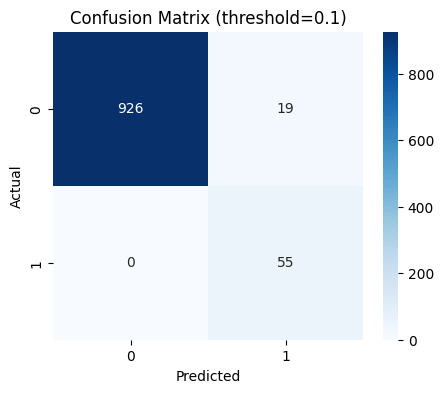

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'Electricity_Consumed',
    'Temperature',
    'Humidity',
    'Wind_Speed',
    'Avg_Past_Consumption',
    'Consumption_Diff'
]

X = df[features]
y = df['Anomaly_Label']

split = int(0.8 * len(df))

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight={0:1, 1:8},
    random_state=42
)

rf_model.fit(X_train, y_train)

y_prob = rf_model.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.3, 0.2, 0.1, 0.08, 0.075]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)

    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))

best_threshold = 0.1
y_pred = (y_prob > best_threshold).astype(int)

print("\nFinal Evaluation:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (threshold={best_threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#حساب الـ probabilities  .ravel()→ بتحول الناتج من شكل (matrix) لشكل array 1D
# [[0.1], [0.2]] تبقى [0.1, 0.2]عني بدل
lstm_prob = lstm_model.predict(X_test_seq).ravel()
#predict_proba→ بيرجع احتمال كل class (0 و 1)
#[:, 1]→ بناخد بس احتمال الـ class = 1(anomaly)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [ ]:
# Expert System (Decision Layer)
# الهدف:
# تحويل outputs من LSTM و Random Forest إلى قرار نهائي مفهوم

def expert_system(lstm_p, rf_p,
                  lstm_threshold=0.075,
                  rf_threshold=0.3):

    # 1) حالة الاتفاق التام (Normal)
    # لو الاتنين أقل من threshold
    if lstm_p < lstm_threshold and rf_p < rf_threshold:
        return {
            "final_model": "Both Models",
            "status": "Normal",
            "risk": "Low",
            "probability": float(max(lstm_p, rf_p)),
            "agreement": "Full Agreement (Normal)",
            "reason": "Both LSTM and Random Forest detect normal consumption"
        }

    # 2) تحديد النموذج الأكثر ثقة

    # LSTM أقوى بشكل واضح
    if lstm_p > rf_p + 0.2:
        chosen_model = "LSTM"
        prob = lstm_p
        threshold = lstm_threshold

    # Random Forest أقوى بشكل واضح
    elif rf_p > lstm_p + 0.2:
        chosen_model = "Random Forest"
        prob = rf_p
        threshold = rf_threshold

    # الفرق بسيط
    else:
        chosen_model = "LSTM" if lstm_p >= rf_p else "Random Forest"
        prob = max(lstm_p, rf_p)
        threshold = lstm_threshold if chosen_model == "LSTM" else rf_threshold

    # 3) تحويل الاحتمال إلى مستوى خطر

    if prob < threshold:
        status = "Normal"
        risk = "Low"

    elif prob < 0.5:
        status = "Suspicious"
        risk = "Medium"

    elif prob < 0.9:
        status = "Anomaly"
        risk = "High"

    else:
        status = "Critical"
        risk = "Very High"

    # 4) حساب درجة الاتفاق بين النموذجين
    agreement_score = 1 - abs(lstm_p - rf_p)

    # 5) إخراج النتيجة النهائية
    return {
        "final_model": chosen_model,
        "lstm_prob": float(lstm_p),
        "rf_prob": float(rf_p),
        "probability": float(prob),
        "status": status,
        "risk": risk,
        "agreement_score": float(agreement_score),
        "agreement": "High" if agreement_score > 0.8 else "Low",
        "reason": f"Decision based on {chosen_model} with threshold logic"
    }

In [ ]:
# تطبيق الـ Expert System على كل بيانات الاختبار
# الهدف:
# تحويل كل زوج (LSTM probability + RF probability)
# إلى قرار نهائي (Normal / Suspicious / Anomaly / Critical)

# ليست فاضية هنخزن فيها نتائج كل sample
results = []

# loop على كل sample في الداتا
for i in range(len(lstm_prob)):

    # ندي لكل sample احتمالاته
    result = expert_system(
        lstm_prob[i],
        rf_prob[i]
    )

    # تخزين النتيجة النهائية في list
    results.append(result)

In [ ]:
#عدد كل حالة
df_results['status'].value_counts()

,count
status,
Normal,797
Suspicious,128
Anomaly,60
Critical,5


In [ ]:
#هوزع المخاطر
df_results['risk'].value_counts()


,count
risk,
Low,797
Medium,128
High,60
Very High,5


In [ ]:

#  Create Comparison Table
# مقارنة نتائج LSTM و Random Forest مع قرار الـ Expert System النهائي

# أولاً: لتأكد إن كل القوائم بنفس الطول
n = min(len(lstm_prob), len(rf_prob), len(df_results))

# بناء DataFrame للمقارنة
comparison = pd.DataFrame({
    # احتمال LSTM لكل عينة
    "LSTM_Probability": lstm_prob[:n],

    # احتمال Random Forest لكل عينة
    "RF_Probability": rf_prob[:n],

    # القرار النهائي من الـ Expert System
    "Final_Status": df_results['status'][:n],

    # مستوى الخطورة
    "Risk_Level": df_results['risk'][:n],

    # الموديل المستخدم في القرار
    "Chosen_Model": df_results['final_model'][:n]
})

# عرض أول 5 صفوف
comparison.head()

,LSTM_Probability,RF_Probability,Final_Status,Risk_Level,Chosen_Model
0,0.060354,0.004550,Normal,Low,Both Models
1,0.045838,0.001915,Normal,Low,Both Models
2,0.055432,0.000900,Normal,Low,Both Models
3,0.073936,0.001294,Normal,Low,Both Models
4,0.135205,0.012663,Suspicious,Medium,LSTM


In [ ]:
import pandas as pd

# التأكد إن كل القوائم بنفس الطول
n = min(len(lstm_prob), len(rf_prob), len(df_results))

# إنشاء جدول المقارنة بين LSTM و Random Forest ونتائج الـ Expert System
comparison = pd.DataFrame({
    "LSTM_Probability": lstm_prob[:n],   # احتمال LSTM
    "RF_Probability": rf_prob[:n],       # احتمال Random Forest
    "Final_Status": df_results['status'][:n],  # القرار النهائي من الـ Expert System
    "Risk_Level": df_results['risk'][:n],      # مستوى الخطورة
    "Chosen_Model": df_results['final_model'][:n]  # الموديل الذي تم اختياره
})

# حساب الفرق بين توقعات LSTM و RF لمعرفة مدى الاختلاف بينهم
comparison["Model_Difference"] = abs(
    comparison["LSTM_Probability"] - comparison["RF_Probability"]
)

# قياس درجة اتفاق الموديلات (كلما زادت القيمة يعني توافق أعلى)
comparison["Model_Agreement"] = comparison["LSTM_Probability"] * comparison["RF_Probability"]

# عرض عينة عشوائية من النتائج لتمثيل كل الحالات (Normal / Anomaly / Critical)
comparison.sample(10)

,LSTM_Probability,RF_Probability,Final_Status,Risk_Level,Chosen_Model,Model_Difference,Model_Agreement
106,0.018028,0.005384,Normal,Low,Both Models,0.012644,0.000097
25,0.112961,0.001179,Suspicious,Medium,LSTM,0.111782,0.000133
797,0.231233,0.365427,Suspicious,Medium,Random Forest,0.134194,0.084499
294,0.603561,0.000706,Anomaly,High,LSTM,0.602855,0.000426
782,0.035427,0.037918,Normal,Low,Both Models,0.002491,0.001343
514,0.022398,0.001948,Normal,Low,Both Models,0.020450,0.000044
571,0.020996,0.001002,Normal,Low,Both Models,0.019994,0.000021
756,0.020221,0.002213,Normal,Low,Both Models,0.018008,0.000045
711,0.043382,0.001786,Normal,Low,Both Models,0.041596,0.000077
567,0.028591,0.003344,Normal,Low,Both Models,0.025247,0.000096


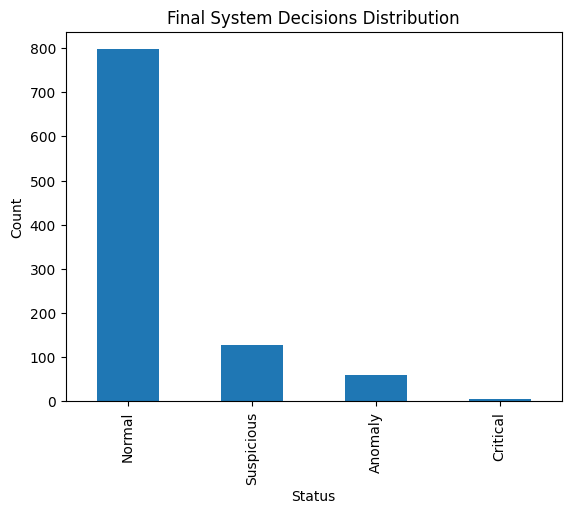

In [ ]:
import matplotlib.pyplot as plt

comparison["Final_Status"].value_counts().plot(kind="bar")
plt.title("Final System Decisions Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

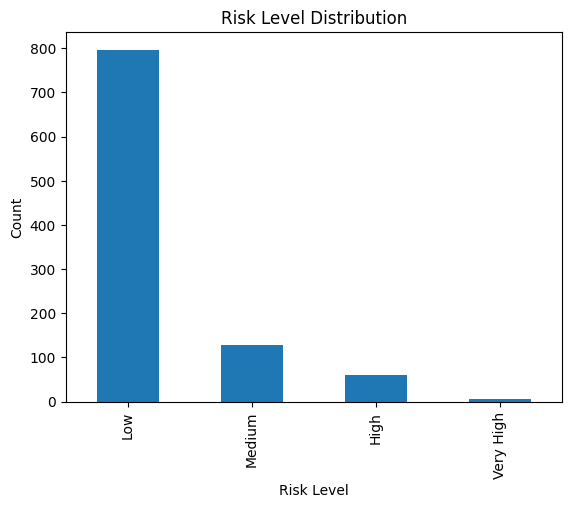

In [ ]:
comparison["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

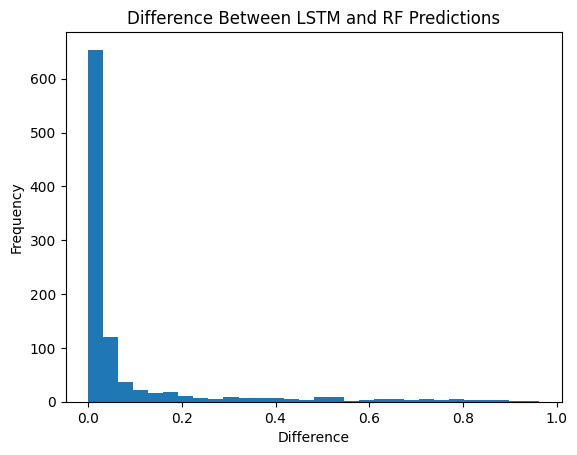

In [ ]:
plt.hist(comparison["Model_Difference"], bins=30)
plt.title("Difference Between LSTM and RF Predictions")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import random
import time
import pandas as pd

# عدد العينات اللي عايزين نولدها
num_samples = 1000

data = []

for i in range(num_samples):

    # -----------------------------
    # 1. توليد القيم الطبيعية
    # -----------------------------
    base_consumption = random.uniform(2, 4)

    # نقرر هل دي anomaly ولا لا
    is_anomaly = random.random() < 0.1  # 10% anomalies

    if is_anomaly:
        # استهلاك غير طبيعي (سرقة أو spike)
        consumption = random.uniform(6, 10)
    else:
        consumption = base_consumption

    temperature = random.uniform(20, 35)
    humidity = random.uniform(30, 70)
    wind_speed = random.uniform(0, 10)

    avg_past = base_consumption + random.uniform(-0.5, 0.5)

    consumption_diff = consumption - avg_past

    # -----------------------------
    # 2. حفظ البيانات
    # -----------------------------
    data.append([
        consumption,
        temperature,
        humidity,
        wind_speed,
        avg_past,
        consumption_diff,
        int(is_anomaly)
    ])

# -----------------------------
# 3. تحويل لـ DataFrame
# -----------------------------
df_sim = pd.DataFrame(data, columns=[
    'Electricity_Consumed',
    'Temperature',
    'Humidity',
    'Wind_Speed',
    'Avg_Past_Consumption',
    'Consumption_Diff',
    'Anomaly_Label'
])

# -----------------------------
# 4. حفظ الملف
# -----------------------------
df_sim.to_csv("simulated_data.csv", index=False)

print("Simulation Done ✅")
df_sim.head()

Simulation Done ✅


,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Consumption_Diff,Anomaly_Label
0,2.896574,21.286770,51.529762,6.149264,2.570759,0.325815,0
1,3.934768,28.196693,61.610916,8.694044,3.610667,0.324101,0
2,2.201846,27.538002,66.861137,8.488067,2.509755,-0.307910,0
3,3.688199,22.454718,49.737634,6.681099,4.032528,-0.344329,0
4,2.527829,24.860144,37.304378,0.610702,2.136570,0.391259,0


In [ ]:
import random
import time

while True:
    consumption = random.uniform(2, 4)

    if random.random() < 0.1:
        consumption = random.uniform(6, 10)  # anomaly

    print(f"Consumption: {consumption:.2f}")

    time.sleep(1)

Consumption: 2.94
Consumption: 2.36
Consumption: 3.39
Consumption: 2.23
Consumption: 2.59
Consumption: 2.94
Consumption: 3.92
Consumption: 3.52
Consumption: 2.82
Consumption: 7.05
Consumption: 3.25
Consumption: 3.33
Consumption: 8.53
Consumption: 2.89
Consumption: 8.55
Consumption: 2.41
Consumption: 3.87
Consumption: 2.73
Consumption: 2.48
Consumption: 9.71
Consumption: 3.68
Consumption: 2.06
Consumption: 3.55
Consumption: 2.38
Consumption: 2.57
Consumption: 3.38
Consumption: 3.54
Consumption: 6.78
Consumption: 2.23
Consumption: 7.55
Consumption: 2.17
Consumption: 2.75
Consumption: 2.43
Consumption: 3.49
Consumption: 2.02


KeyboardInterrupt: 

In [ ]:
import random
import time

running = True

try:
    while running:

        consumption = random.uniform(2, 4)

        if random.random() < 0.1:
            consumption = random.uniform(6, 10)

        temperature = random.uniform(20, 35)
        humidity = random.uniform(30, 70)
        wind_speed = random.uniform(0, 10)
        avg_past = random.uniform(2, 4)

        consumption_diff = consumption - avg_past

        sample = {
            'Electricity_Consumed': consumption,
            'Temperature': temperature,
            'Humidity': humidity,
            'Wind_Speed': wind_speed,
            'Avg_Past_Consumption': avg_past,
            'Consumption_Diff': consumption_diff
        }
#كل ثانية sample جديد
        print(sample)

        time.sleep(1)

except KeyboardInterrupt:
    print("🛑 Simulation Stopped by User")

{'Electricity_Consumed': 2.80570818064336, 'Temperature': 22.252572225082382, 'Humidity': 58.75370304441594, 'Wind_Speed': 8.037824815051563, 'Avg_Past_Consumption': 2.627790965634209, 'Consumption_Diff': 0.1779172150091508}
{'Electricity_Consumed': 7.294805121295301, 'Temperature': 34.93036280406575, 'Humidity': 64.49070170790478, 'Wind_Speed': 6.1374152063202905, 'Avg_Past_Consumption': 2.1640838175534514, 'Consumption_Diff': 5.13072130374185}
{'Electricity_Consumed': 2.5647265408086977, 'Temperature': 27.966430158066665, 'Humidity': 56.84646968272659, 'Wind_Speed': 9.477874872685252, 'Avg_Past_Consumption': 3.721544549886476, 'Consumption_Diff': -1.1568180090777784}
{'Electricity_Consumed': 3.5080570704398943, 'Temperature': 23.313900916133733, 'Humidity': 44.372517446890306, 'Wind_Speed': 7.873921451639081, 'Avg_Past_Consumption': 2.443589929202806, 'Consumption_Diff': 1.0644671412370883}
{'Electricity_Consumed': 2.5783846498766705, 'Temperature': 34.91579268575986, 'Humidity': 42.

In [ ]:
import joblib
from google.colab import files
import inspect
from datetime import datetime

# إنشاء timestamp عشان كل مرة يبقى اسم مختلف
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# أسماء مميزة للفايلات
lstm_filename = f"powerguard_LSTM_v1_{timestamp}.keras"
rf_filename = f"powerguard_RF_v1_{timestamp}.pkl"
results_filename = f"powerguard_results_v1_{timestamp}.csv"
expert_filename = f"powerguard_expert_v1_{timestamp}.py"

# حفظ موديل LSTM
lstm_model.save(lstm_filename)

# حفظ موديل Random Forest
joblib.dump(model, rf_filename)

# حفظ النتائج (اختياري)
df_results.to_csv(results_filename, index=False)

# حفظ كود الـ Expert System
with open(expert_filename, "w") as f:
    f.write(inspect.getsource(expert_system))

# تحميل الملفات
files.download(lstm_filename)
files.download(rf_filename)
files.download(results_filename)
files.download(expert_filename)

print("Files saved with unique names ✅")
print(lstm_filename)
print(rf_filename)
print(results_filename)
print(expert_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files saved with unique names ✅
powerguard_LSTM_v1_20260419_1007.keras
powerguard_RF_v1_20260419_1007.pkl
powerguard_results_v1_20260419_1007.csv
powerguard_expert_v1_20260419_1007.py


In [ ]:
import random
import time

def generate_sample():
    """Generate one simulated smart meter reading"""

    consumption = random.uniform(2, 4)

    # simulate anomaly
    if random.random() < 0.1:
        consumption = random.uniform(6, 10)

    temperature = random.uniform(20, 35)
    humidity = random.uniform(30, 70)
    wind_speed = random.uniform(0, 10)
    avg_past = random.uniform(2, 4)

    consumption_diff = consumption - avg_past

    return {
        'Electricity_Consumed': round(consumption, 2),
        'Temperature': round(temperature, 2),
        'Humidity': round(humidity, 2),
        'Wind_Speed': round(wind_speed, 2),
        'Avg_Past_Consumption': round(avg_past, 2),
        'Consumption_Diff': round(consumption_diff, 2)
    }


# =========================
# Simulation Control
# =========================
running = True

print("⚡ Simulation Started... (Press CTRL + C to stop)\n")

try:
    while running:

        sample = generate_sample()

        # =========================
        # SIMPLE RULE-BASED ACTION (Expert-like behavior)
        # =========================
        if sample["Electricity_Consumed"] > 7:
            status = "🚨 ANOMALY"
            action = "Send Alert"
        elif sample["Electricity_Consumed"] > 5:
            status = "⚠️ Suspicious"
            action = "Monitor"
        else:
            status = "✅ Normal"
            action = "No Action"

        # =========================
        # OUTPUT
        # =========================
        print("\n=========================")
        print("📊 Sample Data:", sample)
        print("📌 Status:", status)
        print("⚙️ Action:", action)
        print("=========================")

        time.sleep(1)

except KeyboardInterrupt:
    running = False
    print("\n🛑 Simulation Stopped by User")

⚡ Simulation Started... (Press CTRL + C to stop)


📊 Sample Data: {'Electricity_Consumed': 2.5, 'Temperature': 23.91, 'Humidity': 40.88, 'Wind_Speed': 2.27, 'Avg_Past_Consumption': 2.65, 'Consumption_Diff': -0.15}
📌 Status: ✅ Normal
⚙️ Action: No Action

📊 Sample Data: {'Electricity_Consumed': 2.39, 'Temperature': 31.42, 'Humidity': 57.11, 'Wind_Speed': 9.12, 'Avg_Past_Consumption': 3.5, 'Consumption_Diff': -1.11}
📌 Status: ✅ Normal
⚙️ Action: No Action

📊 Sample Data: {'Electricity_Consumed': 2.71, 'Temperature': 31.75, 'Humidity': 42.98, 'Wind_Speed': 0.87, 'Avg_Past_Consumption': 3.92, 'Consumption_Diff': -1.2}
📌 Status: ✅ Normal
⚙️ Action: No Action

📊 Sample Data: {'Electricity_Consumed': 2.36, 'Temperature': 24.74, 'Humidity': 60.85, 'Wind_Speed': 7.43, 'Avg_Past_Consumption': 2.16, 'Consumption_Diff': 0.2}
📌 Status: ✅ Normal
⚙️ Action: No Action

📊 Sample Data: {'Electricity_Consumed': 3.02, 'Temperature': 31.86, 'Humidity': 40.39, 'Wind_Speed': 9.38, 'Avg_Past_Consumption': 2.4

In [ ]:
import random
import time

def generate_sample():
    """Generate a single smart meter reading"""

    consumption = random.uniform(2, 4)

    # simulate occasional anomaly spikes
    if random.random() < 0.1:
        consumption = random.uniform(6, 10)

    temperature = random.uniform(20, 35)
    humidity = random.uniform(30, 70)
    wind_speed = random.uniform(0, 10)
    avg_past = random.uniform(2, 4)

    consumption_diff = consumption - avg_past

    return {
        'Electricity_Consumed': round(consumption, 2),
        'Temperature': round(temperature, 2),
        'Humidity': round(humidity, 2),
        'Wind_Speed': round(wind_speed, 2),
        'Avg_Past_Consumption': round(avg_past, 2),
        'Consumption_Diff': round(consumption_diff, 2)
    }


# simulation control flag
running = True

print("⚡ Smart Meter Simulation Started (Press CTRL + C to stop)\n")

try:
    step = 1

    while running:

        sample = generate_sample()

        # simple intelligent rule layer (light expert system logic)
        consumption = sample["Electricity_Consumed"]

        if consumption >= 7:
            status = "CRITICAL ANOMALY"
            action = "🚨 Immediate Alert Sent"
            color = "RED"

        elif consumption >= 5:
            status = "SUSPICIOUS ACTIVITY"
            action = "⚠️ Monitoring Activated"
            color = "ORANGE"

        else:
            status = "NORMAL OPERATION"
            action = "✅ No Action Required"
            color = "GREEN"

        # display output
        print(f"\n--- Reading #{step} ---")
        print("Data:", sample)
        print("Status:", status)
        print("Action:", action)

        step += 1

        time.sleep(1)

except KeyboardInterrupt:
    running = False
    print("\n🛑 Simulation Stopped Successfully by User")

⚡ Smart Meter Simulation Started (Press CTRL + C to stop)


--- Reading #1 ---
Data: {'Electricity_Consumed': 3.22, 'Temperature': 32.17, 'Humidity': 52.33, 'Wind_Speed': 9.67, 'Avg_Past_Consumption': 2.15, 'Consumption_Diff': 1.07}
Status: NORMAL OPERATION
Action: ✅ No Action Required

--- Reading #2 ---
Data: {'Electricity_Consumed': 4.0, 'Temperature': 29.06, 'Humidity': 65.73, 'Wind_Speed': 2.86, 'Avg_Past_Consumption': 3.06, 'Consumption_Diff': 0.94}
Status: NORMAL OPERATION
Action: ✅ No Action Required

--- Reading #3 ---
Data: {'Electricity_Consumed': 2.78, 'Temperature': 25.25, 'Humidity': 67.77, 'Wind_Speed': 7.19, 'Avg_Past_Consumption': 3.86, 'Consumption_Diff': -1.09}
Status: NORMAL OPERATION
Action: ✅ No Action Required

--- Reading #4 ---
Data: {'Electricity_Consumed': 3.53, 'Temperature': 31.6, 'Humidity': 44.5, 'Wind_Speed': 5.46, 'Avg_Past_Consumption': 3.32, 'Consumption_Diff': 0.21}
Status: NORMAL OPERATION
Action: ✅ No Action Required

--- Reading #5 ---
Data: {'Ele